# 📓 Notebook 6: Comparação de Modelos com Técnicas de Ensemble (Logistic Regression + XGBoost)

Este notebook carrega e compara as abordagens de **Voting** e **Blending** nos três cenários:
1. **Base:** Dados originais (sem tratamento).
2. **SMOTE:** Apenas oversampling.
3. **SMOTE + SLM Augmentation:** Oversampling aliado ao enriquecimento de textos.

In [1]:
import os
import pickle
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

from pipeline.utils.extras import divide_mbti
from pipeline.machine_learning_algorithms.logistic_regression import LogisticRegressionClassifier
from pipeline.machine_learning_algorithms.xgboost import XGBoostClassifier
from pipeline.machine_learning_algorithms.ensemble import MBTIEnsembleClassifier

# 1. Carregando os Dados de Teste
with open('data/test_datasets/X_test_tfidf.pkl', 'rb') as f:
    X_test_tfidf = pickle.load(f)
with open('data/test_datasets/y_test.pkl', 'rb') as f:
    y_test_raw = pd.Series(pickle.load(f))
    
y_test_4cols = divide_mbti(y_test_raw)

# 2. Carregando Treino (Usado apenas para ajustar o meta-modelo do Blending)
with open('data/train_datasets/X_train_tfidf.pkl', 'rb') as f:
    X_train_tfidf = pickle.load(f)
with open('data/train_datasets/y_train.pkl', 'rb') as f:
    y_train = pd.Series(pickle.load(f))

X_train_orig_tfidf = X_train_tfidf[:6940]
y_train_orig = y_train[:6940]
y_train_4cols_orig = divide_mbti(y_train_orig)

dimensoes = ['I_E', 'N_S', 'T_F', 'J_P']
nomes_eixos = ['I/E\n(Introvert/Extravert)', 'N/S\n(Intuition/Sensing)', 'T/F\n(Thinking/Feeling)', 'J/P\n(Judging/Perceiving)']

## 🛠️ 2. Função Auxiliar para Carregar o Esquadrão e Gerar Previsões

In [2]:
def rodar_cenario_ensemble(sufixo_lr, sufixo_xgb, nome_cenario, resultados_f1):
    caminho_lr = 'models/logistic_regression'
    caminho_xgb = 'models/xgboost'
    
    clf_lr = LogisticRegressionClassifier(random_state=42)
    clf_xgb = XGBoostClassifier(random_state=42)
    
    for dim in dimensoes:
        arquivo_lr = f"{caminho_lr}/{dim}_{sufixo_lr}.pkl"
        arquivo_xgb = f"{caminho_xgb}/{dim}_{sufixo_xgb}.json"
        
        clf_lr.models[dim] = joblib.load(arquivo_lr)
        clf_xgb.models[dim].load_model(arquivo_xgb)
        
    base_models = {'LogisticRegression': clf_lr, 'XGBoost': clf_xgb}
    print(f"✅ Cenário '{nome_cenario}' carregado com sucesso!")
    
    ensemble_voting = MBTIEnsembleClassifier(models_dict=base_models, ensemble_type='voting')
    ensemble_voting.fit(X_train_orig_tfidf, y_train_4cols_orig)
    pred_voting = ensemble_voting.predict(X_test_tfidf)
    
    ensemble_blending = MBTIEnsembleClassifier(models_dict=base_models, ensemble_type='blending')
    ensemble_blending.fit(X_train_orig_tfidf, y_train_4cols_orig)
    pred_blending = ensemble_blending.predict(X_test_tfidf)
    
    for i, col in enumerate(dimensoes):
        f1_voting = f1_score(y_test_4cols[col], pred_voting[col], average='weighted') * 100
        f1_blending = f1_score(y_test_4cols[col], pred_blending[col], average='weighted') * 100
        
        resultados_f1.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_voting, 'Cenário': nome_cenario, 'Ensemble': 'Voting'})
        resultados_f1.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_blending, 'Cenário': nome_cenario, 'Ensemble': 'Blending'})
        
    print(f"🎯 Previsões geradas!\n")

## 🏃‍♀️ 3. Execução dos Três Cenários

In [3]:
resultados_f1 = []

# 1: Base (No SMOTE)
rodar_cenario_ensemble(
    sufixo_lr="posts_tfidf_linear",
    sufixo_xgb="tfidf_qwen_original_posts",
    nome_cenario="Base (No SMOTE)",
    resultados_f1=resultados_f1
)

# 2: SMOTE
rodar_cenario_ensemble(
    sufixo_lr="posts_tfidf_linear_oversampled",
    sufixo_xgb="posts_tfidf_oversampled",
    nome_cenario="Apenas SMOTE",
    resultados_f1=resultados_f1
)

# 3: SMOTE + SLM Augmentation
rodar_cenario_ensemble(
    sufixo_lr="tfidf_linear",
    sufixo_xgb="tfidf_qwen",
    nome_cenario="SMOTE + SLM Augmentation",
    resultados_f1=resultados_f1
)

✅ Cenário 'Base (No SMOTE)' carregado com sucesso!
Starting voting ensemble training process...
 -> Fitting voting model for I_E...
 -> Fitting voting model for N_S...
 -> Fitting voting model for T_F...
 -> Fitting voting model for J_P...
All 4 ensemble dimensions fitted successfully! ✅
Starting blending ensemble training process...
 -> Fitting blending model for I_E...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

 -> Fitting blending model for N_S...
 -> Fitting blending model for T_F...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: inva

 -> Fitting blending model for J_P...
All 4 ensemble dimensions fitted successfully! ✅


...

All 4 ensemble dimensions fitted successfully! ✅
🎯 Previsões geradas!

✅ Cenário 'SMOTE + SLM Augmentation' carregado com sucesso!
Starting voting ensemble training process...
 -> Fitting voting model for I_E...
 -> Fitting voting model for N_S...
 -> Fitting voting model for T_F...
 -> Fitting voting model for J_P...
All 4 ensemble dimensions fitted successfully! ✅
Starting blending ensemble training process...
 -> Fitting blending model for I_E...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

 -> Fitting blending model for N_S...
 -> Fitting blending model for T_F...
 -> Fitting blending model for J_P...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: inva

All 4 ensemble dimensions fitted successfully! ✅
🎯 Previsões geradas!



## 📊 4. Gráfico Comparativo Final

/var/folders/5z/_8ywj3rn11x3yfxv7mczhpmh0000gn/T/ipykernel_28612/1627570728.py:28: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5z/_8ywj3rn11x3yfxv7mczhpmh0000gn/T/ipykernel_28612/1627570728.py:28: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


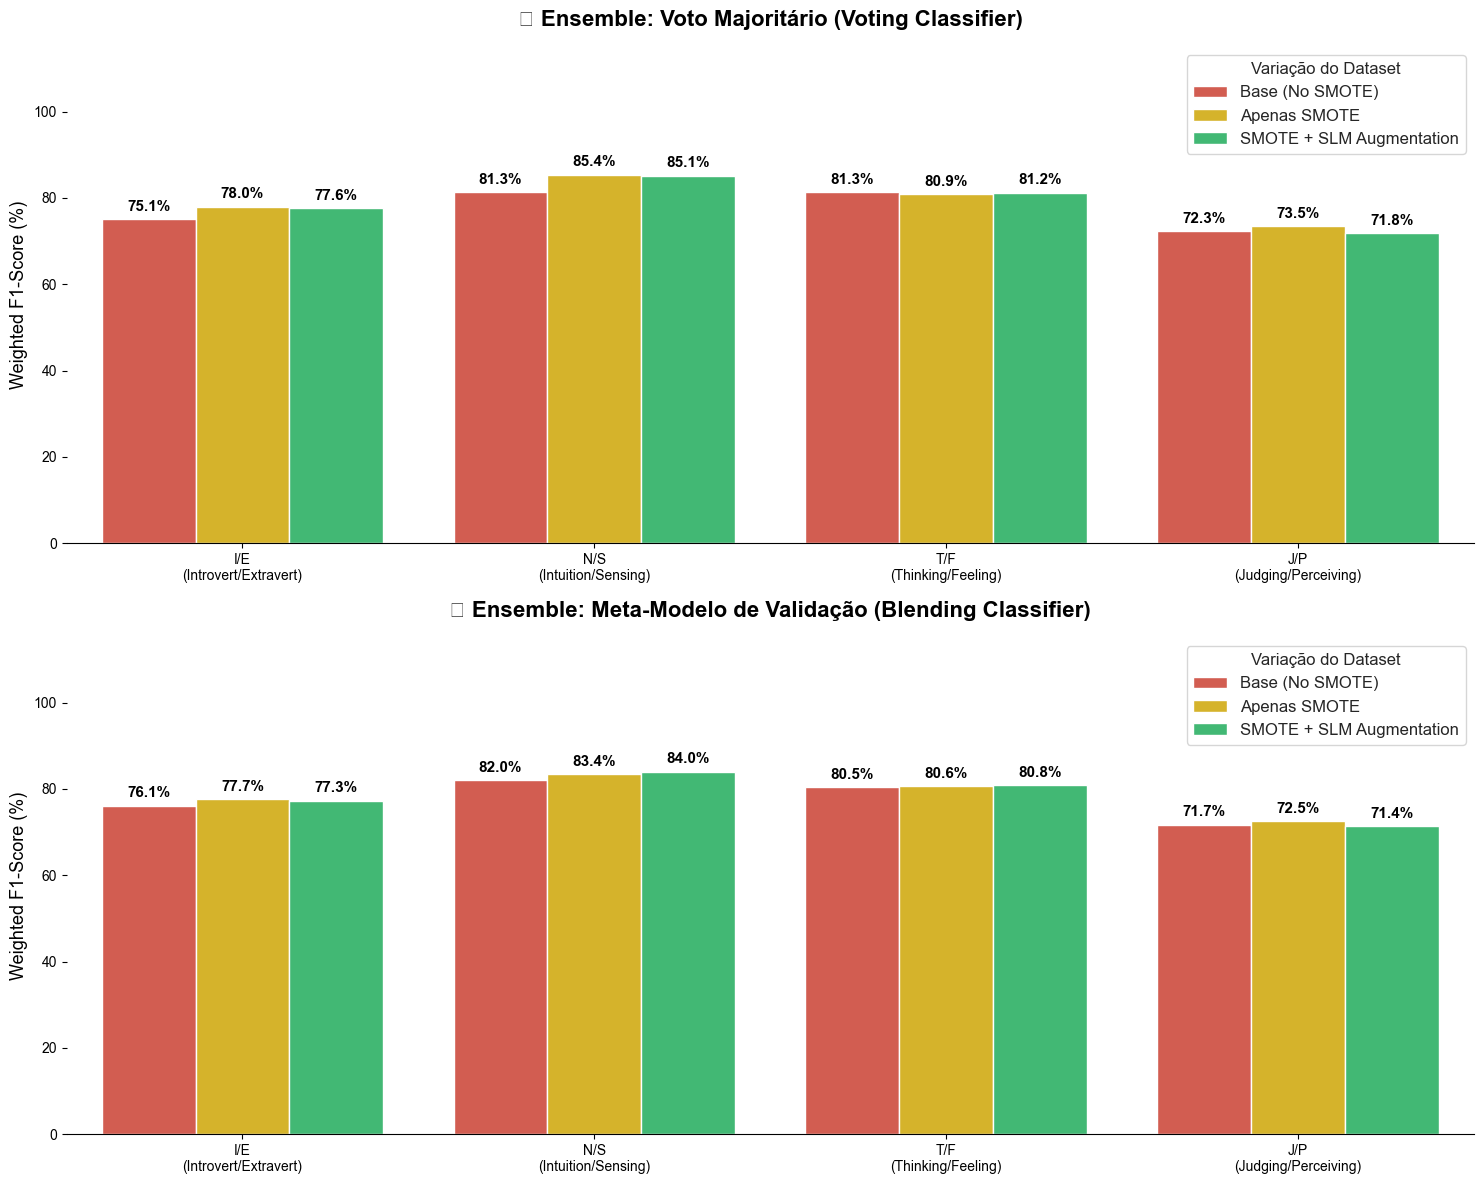

In [4]:
df_plot = pd.DataFrame(resultados_f1)

fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharey=True)
sns.set_theme(style="whitegrid")
paleta = ['#e74c3c', '#f1c40f', '#2ecc71']

sns.barplot(data=df_plot[df_plot['Ensemble'] == 'Voting'], x='Axis', y='F1 (%)', hue='Cenário', palette=paleta, ax=axes[0])
axes[0].set_title("🏆 Ensemble: Voto Majoritário (Voting Classifier)", fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("Weighted F1-Score (%)", fontsize=13)
axes[0].set_xlabel("")

sns.barplot(data=df_plot[df_plot['Ensemble'] == 'Blending'], x='Axis', y='F1 (%)', hue='Cenário', palette=paleta, ax=axes[1])
axes[1].set_title("🧠 Ensemble: Meta-Modelo de Validação (Blending Classifier)", fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel("Weighted F1-Score (%)", fontsize=13)
axes[1].set_xlabel("")

for ax in axes:
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.annotate(f"{altura:.1f}%", (p.get_x() + p.get_width() / 2., altura), 
                        ha='center', va='baseline', fontsize=11, fontweight='bold', color='black', 
                        xytext=(0, 6), textcoords='offset points')
    ax.legend(title='Variação do Dataset', fontsize='12', loc='upper right')

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()